In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import cv2

In [107]:
import torchvision.models as models
import torch

In [108]:
from torchsummary import summary

In [109]:
single_img = plt.imread("/kaggle/input/images_001/images/00000001_000.png")

In [110]:
single_img.shape

(1024, 1024)

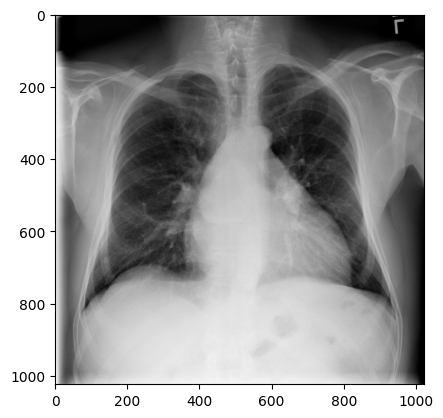

In [111]:
plt.imshow(single_img,cmap="gray")

In [112]:
data = pd.read_csv("/kaggle/input/Data_Entry_2017.csv")

In [113]:
data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168,0.168,NaN
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168,0.168,NaN
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168,NaN
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168,0.168,NaN


In [114]:
all_columns = data.columns

In [115]:
all_columns = list(all_columns)

In [116]:
useful_columns = all_columns[0:2] + all_columns[7:11]

In [117]:
useful_columns

['Image Index',
 'Finding Labels',
 'OriginalImage[Width',
 'Height]',
 'OriginalImagePixelSpacing[x',
 'y]']

In [118]:
useful_data = data[useful_columns]

In [119]:
useful_data

,Image Index,Finding Labels,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,2582,2991,0.143,0.143
...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,2048,2500,0.168,0.168
112116,00030802_000.png,No Finding,2048,2500,0.168,0.168
112117,00030803_000.png,No Finding,2048,2500,0.168,0.168
112118,00030804_000.png,No Finding,2048,2500,0.168,0.168


In [120]:
path_list = list()
file_names = list()
for absolute_path in pathlib.Path("/kaggle/input").glob("images_*/images/*.png"):

    path_list.append(str(absolute_path))
    file_names.append(str(absolute_path).split("/")[-1])

In [121]:
path_list.sort()

In [122]:
path_list[0:5]

['/kaggle/input/images_001/images/00000001_000.png',
 '/kaggle/input/images_001/images/00000001_001.png',
 '/kaggle/input/images_001/images/00000001_002.png',
 '/kaggle/input/images_001/images/00000002_000.png',
 '/kaggle/input/images_001/images/00000003_000.png']

In [123]:
useful_data["Image Path"] = path_list

/tmp/ipykernel_35/985072719.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_data["Image Path"] = path_list


In [124]:
useful_data

,Image Index,Finding Labels,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Image Path
0,00000001_000.png,Cardiomegaly,2682,2749,0.143,0.143,/kaggle/input/images_001/images/00000001_000.png
1,00000001_001.png,Cardiomegaly|Emphysema,2894,2729,0.143,0.143,/kaggle/input/images_001/images/00000001_001.png
2,00000001_002.png,Cardiomegaly|Effusion,2500,2048,0.168,0.168,/kaggle/input/images_001/images/00000001_002.png
3,00000002_000.png,No Finding,2500,2048,0.171,0.171,/kaggle/input/images_001/images/00000002_000.png
4,00000003_000.png,Hernia,2582,2991,0.143,0.143,/kaggle/input/images_001/images/00000003_000.png
...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030801_001.png
112116,00030802_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030802_000.png
112117,00030803_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030803_000.png
112118,00030804_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030804_000.png


In [125]:
unique_diseases = set()
for disease in useful_data["Finding Labels"]:
    unique_diseases.update(set(disease.split("|")))

In [126]:
unique_diseases = list(unique_diseases)
unique_diseases.remove("No Finding")

In [127]:
unique_diseases

['Pneumothorax',
 'Fibrosis',
 'Consolidation',
 'Hernia',
 'Atelectasis',
 'Infiltration',
 'Mass',
 'Effusion',
 'Cardiomegaly',
 'Emphysema',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Edema']

In [128]:
diseases2idx = dict(zip(unique_diseases,range(len(unique_diseases))))

In [129]:
diseases2idx

{'Pneumothorax': 0,
 'Fibrosis': 1,
 'Consolidation': 2,
 'Hernia': 3,
 'Atelectasis': 4,
 'Infiltration': 5,
 'Mass': 6,
 'Effusion': 7,
 'Cardiomegaly': 8,
 'Emphysema': 9,
 'Nodule': 10,
 'Pleural_Thickening': 11,
 'Pneumonia': 12,
 'Edema': 13}

In [130]:
another_data = pd.read_csv("/kaggle/input/BBox_List_2017.csv")

In [131]:
another_data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
979,00029464_015.png,Atelectasis,198.940451,352.900747,615.537778,323.128889,NaN,NaN,NaN
980,00025769_001.png,Atelectasis,701.838229,572.491858,103.537778,63.715556,NaN,NaN,NaN
981,00016837_002.png,Atelectasis,140.913785,658.962969,271.928889,94.435556,NaN,NaN,NaN
982,00020124_003.png,Atelectasis,175.047118,580.456302,244.622222,103.537778,NaN,NaN,NaN


In [132]:
test_diseases2idx = dict(zip(another_data["Finding Label"].unique(),range(len(unique_diseases))))

In [133]:
test_diseases2idx

{'Atelectasis': 0,
 'Cardiomegaly': 1,
 'Effusion': 2,
 'Infiltrate': 3,
 'Mass': 4,
 'Nodule': 5,
 'Pneumonia': 6,
 'Pneumothorax': 7}

In [134]:
len(another_data["Image Index"].unique())

880

In [135]:
another_data["Image Path"] = another_data["Image Index"].map(useful_data.set_index("Image Index")["Image Path"])

In [136]:
testing_data = another_data

In [137]:
testing_data.rename(columns={"Bbox [x": "x","h]": "h"}, inplace=True)


In [138]:
testing_data

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Image Index,Finding Label,x,y,w,h,Unnamed: 6,Unnamed: 7,Unnamed: 8,Image Path
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN,/kaggle/input/images_006/images/00013118_008.png
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN,/kaggle/input/images_007/images/00014716_007.png
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN,/kaggle/input/images_012/images/00029817_009.png
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN,/kaggle/input/images_007/images/00014687_001.png
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN,/kaggle/input/images_008/images/00017877_001.png
...,...,...,...,...,...,...,...,...,...,...
979,00029464_015.png,Atelectasis,198.940451,352.900747,615.537778,323.128889,NaN,NaN,NaN,/kaggle/input/images_012/images/00029464_015.png
980,00025769_001.png,Atelectasis,701.838229,572.491858,103.537778,63.715556,NaN,NaN,NaN,/kaggle/input/images_011/images/00025769_001.png
981,00016837_002.png,Atelectasis,140.913785,658.962969,271.928889,94.435556,NaN,NaN,NaN,/kaggle/input/images_008/images/00016837_002.png
982,00020124_003.png,Atelectasis,175.047118,580.456302,244.622222,103.537778,NaN,NaN,NaN,/kaggle/input/images_009/images/00020124_003.png


In [139]:
useful_data.set_index(keys="Image Index",drop=False,inplace=True)

In [140]:
useful_data

,Image Index,Finding Labels,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Image Path
Image Index,,,,,,,
00000001_000.png,00000001_000.png,Cardiomegaly,2682,2749,0.143,0.143,/kaggle/input/images_001/images/00000001_000.png
00000001_001.png,00000001_001.png,Cardiomegaly|Emphysema,2894,2729,0.143,0.143,/kaggle/input/images_001/images/00000001_001.png
00000001_002.png,00000001_002.png,Cardiomegaly|Effusion,2500,2048,0.168,0.168,/kaggle/input/images_001/images/00000001_002.png
00000002_000.png,00000002_000.png,No Finding,2500,2048,0.171,0.171,/kaggle/input/images_001/images/00000002_000.png
00000003_000.png,00000003_000.png,Hernia,2582,2991,0.143,0.143,/kaggle/input/images_001/images/00000003_000.png
...,...,...,...,...,...,...,...
00030801_001.png,00030801_001.png,Mass|Pneumonia,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030801_001.png
00030802_000.png,00030802_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030802_000.png
00030803_000.png,00030803_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030803_000.png


In [141]:
useful_data.drop(index=another_data["Image Index"],inplace=True)

/tmp/ipykernel_35/2250962470.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_data.drop(index=another_data["Image Index"],inplace=True)


In [142]:
useful_data.shape

(111240, 7)

In [143]:
training_data = useful_data.reset_index(drop=True)

In [144]:
training_data

,Image Index,Finding Labels,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Image Path
0,00000001_000.png,Cardiomegaly,2682,2749,0.143,0.143,/kaggle/input/images_001/images/00000001_000.png
1,00000001_001.png,Cardiomegaly|Emphysema,2894,2729,0.143,0.143,/kaggle/input/images_001/images/00000001_001.png
2,00000001_002.png,Cardiomegaly|Effusion,2500,2048,0.168,0.168,/kaggle/input/images_001/images/00000001_002.png
3,00000002_000.png,No Finding,2500,2048,0.171,0.171,/kaggle/input/images_001/images/00000002_000.png
4,00000003_000.png,Hernia,2582,2991,0.143,0.143,/kaggle/input/images_001/images/00000003_000.png
...,...,...,...,...,...,...,...
111235,00030801_001.png,Mass|Pneumonia,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030801_001.png
111236,00030802_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030802_000.png
111237,00030803_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030803_000.png
111238,00030804_000.png,No Finding,2048,2500,0.168,0.168,/kaggle/input/images_012/images/00030804_000.png


In [145]:
y_train = list()

for single_img_labels in training_data["Finding Labels"]:

    single_img_multi_hot_vector = np.zeros((len(diseases2idx),))
    diseases = single_img_labels.split("|")

    if "No Finding" not in diseases:
        for single_disease in diseases:

            single_img_multi_hot_vector[diseases2idx[single_disease]] = 1.0

    y_train.append(single_img_multi_hot_vector)

y_train = np.array(y_train)

In [146]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [147]:
y_testing = list()

for single_img_labels in testing_data["Finding Label"]:

    single_img_multi_hot_vector = np.zeros((len(test_diseases2idx),))
    diseases = single_img_labels.split("|")

    for single_disease in diseases:

            single_img_multi_hot_vector[test_diseases2idx[single_disease]] = 1.0

    y_testing.append(single_img_multi_hot_vector)

y_testing = np.array(y_testing)

In [148]:
y_testing

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [149]:
y_testing.shape

(984, 8)

In [150]:
def training_data_mini_batches_generator(training_data_df,mb_size=40):

    for i in range(training_data_df.shape[0]//mb_size):

        img_np_array_mb_list = list()

        for j in range(i*mb_size,(i+1)*mb_size):

            single_img_path = training_data["Image Path"].iloc[j]
            img_np_array = cv2.imread (single_img_path, cv2.IMREAD_COLOR)
            resized_img_np_array = cv2.resize(img_np_array, (224, 224))
            three_channel_np_array = cv2.cvtColor(resized_img_np_array, cv2.COLOR_BGR2RGB) 

            img_np_array_mb_list.append(three_channel_np_array)

        X_train_mb = np.array(img_np_array_mb_list)
        y_train_mb = y_train[i*mb_size:(i+1)*mb_size,:]

        yield X_train_mb, y_train_mb

In [151]:
def testing_data_mini_batches_generator(testing_data_df,mb_size=10):
    grouped = testing_data_df.groupby("Image Index")
    unique_image_names = list(grouped.groups.keys())
    
    for i in range(len(unique_image_names)//mb_size):
        
        X_testing_mb = []
        bbox_mb = []
        
        for j in range(i * mb_size,(i+1) * mb_size):
            
            single_img_name = unique_image_names[j]
            group = grouped.get_group(single_img_name)

            img_path = group["Image Path"].iloc[0]
            img_np_array = plt.imread(img_path)
            original_h, original_w = img.shape[:2]

            resized_img = cv2.resize(img_np_array,(224, 224))
            resized_img = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2RGB)
            X_testing_mb.append(resized_img)

            scaled_boxes = []
            for _, row in group.iterrows():
                try:
                    x_scaled = float(row["x"]) * (224 / original_w)
                    y_scaled = float(row["y"]) * (224 / original_h)
                    w_scaled = float(row["w"]) * (224 / original_w)
                    h_scaled = float(row["h"]) * (224 / original_h)
                    scaled_boxes.append([x_scaled, y_scaled, w_scaled, h_scaled])
                except:
                    continue
                    
            bbox_mb.append(scaled_boxes)
            X_testing_mb = np.array(X_testing_mb)
            y_testing_mb = y_testing[i*mb_size:(i+1)*mb_size,:]

        yield X_train_mb, y_train_mb ,bbox_mb

In [152]:
class our_custom_resnet50_cnn(torch.nn.Module):

    def __init__(self,num_classes):
        super().__init__()

        self.resnet50_full_nw = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1')
        self.custom_resnet_fc = torch.nn.Linear(in_features=self.resnet50_full_nw.fc.in_features,out_features=num_classes)
        self.our_activation_function = torch.nn.Sigmoid()

    def forward(self,X_train_mb):

        our_resnet_50_fc = torch.nn.Sequential(self.custom_resnet_fc,self.our_activation_function)
        self.resnet50_full_nw.fc = our_resnet_50_fc

        y_pred_mb = self.resnet50_full_nw(X_train_mb)

        return y_pred_mb

In [153]:
our_model = our_custom_resnet50_cnn(14)

In [154]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

our_model = our_custom_resnet50_cnn(num_classes=14)
our_model.to(device)

Using device: cuda


our_custom_resnet50_cnn(
  (resnet50_full_nw): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample

In [155]:
for param in our_model.resnet50_full_nw.parameters():
    param.requires_grad = False
    
for param in our_model.custom_resnet_fc.parameters():
    param.requires_grad = True

In [156]:
summary(our_model,input_size=(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [ ]:
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(params = our_model.parameters(),lr=0.001)
epochs = 3
mb_size = 10

for i in range(epochs):
    our_training_datagen = training_data_mini_batches_generator(training_data)

    for X_train_mb, y_train_mb in our_training_datagen:
        # Move to GPU
        X_train_mb_tensor = torch.tensor(X_train_mb, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
        y_train_mb_tensor = torch.tensor(y_train_mb, dtype=torch.float32).to(device)

        y_pred_mb_train = our_model(X_train_mb_tensor)
        training_mb_loss = loss_fn(y_pred_mb_train, y_train_mb_tensor)

        # Backprop + Optimizer
        training_mb_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch #{i+1}, Loss = {training_mb_loss.item():.4f}")

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Epoch #1, Loss = 0.7058
Epoch #1, Loss = 0.7035
Epoch #1, Loss = 0.6919
Epoch #1, Loss = 0.7033
Epoch #1, Loss = 0.6890
Epoch #1, Loss = 0.6814
Epoch #1, Loss = 0.6728
Epoch #1, Loss = 0.6707
Epoch #1, Loss = 0.6680
Epoch #1, Loss = 0.6670
Epoch #1, Loss = 0.6552
Epoch #1, Loss = 0.6596
Epoch #1, Loss = 0.6529
Epoch #1, Loss = 0.6392
Epoch #1, Loss = 0.6258
Epoch #1, Loss = 0.6242
Epoch #1, Loss = 0.6177
Epoch #1, Loss = 0.6160
Epoch #1, Loss = 0.6150
Epoch #1, Loss = 0.5949
Epoch #1, Loss = 0.5941
Epoch #1, Loss = 0.6197
Epoch #1, Loss = 0.5866
Epoch #1, Loss = 0.5837
Epoch #1, Loss = 0.5821
Epoch #1, Loss = 0.5765
Epoch #1, Loss = 0.5650
Epoch #1, Loss = 0.5618
Epoch #1, Loss = 0.5568
Epoch #1, Loss = 0.5476
Epoch #1, Loss = 0.5441
Epoch #1, Loss = 0.5413
Epoch #1, Loss = 0.5447
Epoch #1, Loss = 0.5249
Epoch #1, Loss = 0.5414
Epoch #1, Loss = 0.5369
Epoch #1, Loss = 0.5287
Epoch #1, Loss = 0.5223
Epoch #1, Loss = 0.5265
Epoch #1, Loss = 0.5030
Epoch #1, Loss = 0.5067
Epoch #1, Loss =

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Epoch #1, Loss = 0.2042
Epoch #1, Loss = 0.3213
Epoch #1, Loss = 0.2150
Epoch #1, Loss = 0.2256
Epoch #1, Loss = 0.1890
Epoch #1, Loss = 0.1933
Epoch #1, Loss = 0.2004
Epoch #1, Loss = 0.1934
Epoch #1, Loss = 0.2084
Epoch #1, Loss = 0.1827
Epoch #1, Loss = 0.2083
Epoch #1, Loss = 0.2022
Epoch #1, Loss = 0.2291
Epoch #1, Loss = 0.1961
Epoch #1, Loss = 0.2575
Epoch #1, Loss = 0.2768
Epoch #1, Loss = 0.1915
Epoch #1, Loss = 0.2786
Epoch #1, Loss = 0.2533
Epoch #1, Loss = 0.2402
Epoch #1, Loss = 0.2148
Epoch #1, Loss = 0.3067
Epoch #1, Loss = 0.2100
Epoch #1, Loss = 0.1960
Epoch #1, Loss = 0.1685
Epoch #1, Loss = 0.2032
Epoch #1, Loss = 0.2200
Epoch #1, Loss = 0.1676
Epoch #1, Loss = 0.1993
Epoch #1, Loss = 0.1797
Epoch #1, Loss = 0.1755
Epoch #1, Loss = 0.2136
Epoch #1, Loss = 0.1988
Epoch #1, Loss = 0.1864
Epoch #1, Loss = 0.1794
Epoch #1, Loss = 0.1886
Epoch #1, Loss = 0.2303
Epoch #1, Loss = 0.1950
Epoch #1, Loss = 0.1494
Epoch #1, Loss = 0.1905
Epoch #1, Loss = 0.2165
Epoch #1, Loss =